In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal
from pydantic import BaseModel, Field

In [2]:
model = ChatOllama(model="qwen2.5:3b")

In [3]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(description = 'Sentiment of the review.')

In [4]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [5]:
structured_model = model.with_structured_output(SentimentSchema)

In [6]:
structured_model_for_diagnosis = model.with_structured_output(DiagnosisSchema)

In [7]:
prompt = "what is the sentiment of the following review: the software too good."
structured_model.invoke(prompt).sentiment

'positive'

In [8]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis: dict
    response: str

In [9]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following review find sentiment: \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}

In [10]:
def check_sentiment(state: ReviewState) -> Literal['PositiveResponse', 'RunDiagnosis']:
    if state['sentiment'] == 'positive':
        return 'PositiveResponse'
    else:
        return 'RunDiagnosis'

In [11]:
def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\"{state['review']}\"\n Also, kindly ask the user to leave feedback on our website."""
     
    response = model.invoke(prompt)
    return {'response': response}

In [12]:
def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency."""
    response = structured_model_for_diagnosis.invoke(prompt)
    return {'diagnosis': response.model_dump()}

In [13]:
def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message."""
    response = model.invoke(prompt).content
    return {'response': response}

In [14]:
graph = StateGraph(ReviewState)

graph.add_node('FindSentiment', find_sentiment)
graph.add_node('PositiveResponse', positive_response)
graph.add_node('RunDiagnosis', run_diagnosis)
graph.add_node('NegativeResponse', negative_response)

graph.add_edge(START, 'FindSentiment')
graph.add_conditional_edges('FindSentiment', check_sentiment)
graph.add_edge('PositiveResponse', END)
graph.add_edge('RunDiagnosis', 'NegativeResponse')
graph.add_edge('NegativeResponse', END)

workflow = graph.compile()

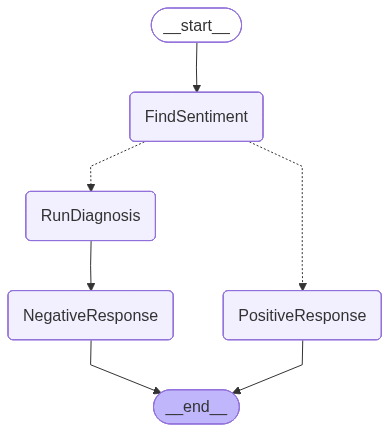

In [15]:
workflow

In [16]:
workflow.invoke({'review': "I've been using this app for about a month now, and I must say, the user interface is incredibly clean and intuitive. Everything is exactly where you'd expect it to be. It's rare to find something that just works without needing a tutorial. Great job to the design team!"})

{'review': "I've been using this app for about a month now, and I must say, the user interface is incredibly clean and intuitive. Everything is exactly where you'd expect it to be. It's rare to find something that just works without needing a tutorial. Great job to the design team!",
 'sentiment': 'positive',
 'response': AIMessage(content="Dear [User],\n\nI am thrilled to hear about your positive experience with our app! Your words of praise are greatly appreciated and I'm delighted you found the user interface both clean and intuitive. It’s wonderful to know that everything is exactly where you'd expect it to be, making for a seamless and enjoyable experience.\n\nYour comments highlight how much effort we put into designing an easy-to-use platform. We value your feedback and it helps us continuously improve our app. Thank you for taking the time to share this with others!\n\nI would like to kindly request that you consider leaving feedback on our website as well. Your insights can he

In [17]:
workflow.invoke({'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."})

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Hi there,\n\nI understand that you're facing quite a challenge with the issue you've described, and I can definitely see how frustrating it must be for you. Your priority is really important to us, and we’re committed to finding a solution as quickly as possible.\n\nCould you please provide more details about the specific problem? The clearer the information, the better our team can assist you in resolving this issue efficiently. We will do everything we can to address your concerns promptly and ensure that it doesn't happen again in the future. \n\nThank you for bringing this to our attention so quickly, and I really appreciate 